# Weis Markets — L&D Impact Analysis: LMS Training vs. Store Revenue

**Purpose:** Correlate store-level LMS training metrics with store-level revenue performance to quantify the business impact of Learning & Development programs.

**Data Sources:**
- `lms_synthetic_validated_100k.csv` — 100,000 employee training records across 241 locations
- `revenue_dataset_240stores.csv` — 240 stores × 820 days of revenue data (Jan 2024 – Mar 2026)

## Section 1: Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Load data ──────────────────────────────────────────────────────────────
lms = pd.read_csv(
    'lms_synthetic_calibrated.csv',
    parse_dates=['Hire Date', 'Assignment Date', 'Complete Date', 'Due Date']
)

rev = pd.read_csv(
    'revenue_dataset_calibrated.csv',
    parse_dates=['Date']
)

print(f"LMS shape  : {lms.shape}")
print(f"Revenue shape: {rev.shape}")
print(f"\nLMS dtypes:\n{lms.dtypes}")
print(f"\nRevenue dtypes:\n{rev.dtypes}")

LMS shape  : (100000, 32)
Revenue shape: (196800, 18)

LMS dtypes:
Employee ID                          int64
First Name                          object
Last Name                           object
Full Name                           object
Hire Date                   datetime64[ns]
Learning Module Code                object
Learning Module Name                object
Learning Module Type                object
Learning Module Category            object
Estimated Duration                   int64
Progress Instance                    int64
Progress ID                         object
Assignment Type                     object
Assignment Date             datetime64[ns]
Due Date                    datetime64[ns]
Complete Date               datetime64[ns]
Progress Status                     object
Total Time                           int64
Satisfied                           object
Past Due                            object
Days Past Due                        int64
Email Address                 

In [2]:
# ── Feature Engineering on LMS ─────────────────────────────────────────────

# Binary flags
lms['Is_Completed']    = (lms['Progress Status'] == 'Completed').astype(int)
lms['Satisfied_Binary']= (lms['Satisfied'] == 'Yes').astype(int)
lms['Is_Past_Due']     = (lms['Past Due'] == 'Yes').astype(int)

# Tenure in years at time of assignment
lms['Tenure_Years'] = (
    (lms['Assignment Date'] - lms['Hire Date']).dt.days / 365.25
).clip(lower=0)

# Ratio of actual time spent vs estimated duration
lms['Time_Ratio'] = np.where(
    lms['Estimated Duration'] > 0,
    lms['Total Time'] / lms['Estimated Duration'],
    np.nan
)

print("Feature engineering complete.")
print(lms[['Is_Completed', 'Satisfied_Binary', 'Is_Past_Due',
           'Tenure_Years', 'Time_Ratio']].describe())

Feature engineering complete.
        Is_Completed  Satisfied_Binary   Is_Past_Due   Tenure_Years  \
count  100000.000000     100000.000000  100000.00000  100000.000000   
mean        0.782130          0.704670       0.32209       2.352740   
std         0.412801          0.456193       0.46728       1.857958   
min         0.000000          0.000000       0.00000       0.019165   
25%         1.000000          0.000000       0.00000       0.752909   
50%         1.000000          1.000000       0.00000       2.028747   
75%         1.000000          1.000000       1.00000       3.524298   
max         1.000000          1.000000       1.00000      12.941821   

          Time_Ratio  
count  100000.000000  
mean        0.819829  
std         0.377940  
min         0.000000  
25%         0.642857  
50%         0.857143  
75%         1.071429  
max         1.800000  


## Section 2: Build Store-Level LMS Features

In [3]:
# Filter out HQ_001 — no revenue match
lms_stores = lms[lms['Location'] != 'HQ_001'].copy()
print(f"LMS records after removing HQ_001: {len(lms_stores):,}")

# ── Dummy columns for categorical breakdowns ────────────────────────────────
lms_stores['is_required']         = (lms_stores['Assignment Type'] == 'Required').astype(int)
lms_stores['is_elearning']        = (lms_stores['Learning Module Type'] == 'eLearning').astype(int)
lms_stores['is_instructor_led']   = (lms_stores['Learning Module Type'] == 'Instructor-Led').astype(int)
lms_stores['is_assessment']       = (lms_stores['Learning Module Type'] == 'Assessment').astype(int)
lms_stores['is_microlearning']    = (lms_stores['Learning Module Type'] == 'Microlearning').astype(int)

lms_stores['is_compliance']       = (lms_stores['Learning Module Category'] == 'Compliance').astype(int)
lms_stores['is_operations']       = (lms_stores['Learning Module Category'] == 'Operations').astype(int)
lms_stores['is_safety']           = (lms_stores['Learning Module Category'] == 'Safety').astype(int)
lms_stores['is_leadership']       = (lms_stores['Learning Module Category'] == 'Leadership').astype(int)
lms_stores['is_customer_exp']     = (lms_stores['Learning Module Category'] == 'Customer Experience').astype(int)
lms_stores['is_sales']            = (lms_stores['Learning Module Category'] == 'Sales').astype(int)
lms_stores['is_technology']       = (lms_stores['Learning Module Category'] == 'Technology').astype(int)
lms_stores['is_hr']               = (lms_stores['Learning Module Category'] == 'Human Resources').astype(int)
lms_stores['is_analytics']        = (lms_stores['Learning Module Category'] == 'Analytics').astype(int)

lms_stores['is_fulltime']         = (lms_stores['FullTimePartTime'] == 'Full Time').astype(int)
lms_stores['is_salaried']         = (lms_stores['Is Salaried'] == True).astype(int)

# ── Aggregate to store level ────────────────────────────────────────────────
def store_agg(df):
    grp = df.groupby('Location')
    agg = pd.DataFrame({
        'completion_rate'          : grp['Is_Completed'].mean(),
        'satisfaction_rate'        : grp['Satisfied_Binary'].mean(),
        'past_due_rate'            : grp['Is_Past_Due'].mean(),
        'avg_total_time'           : grp['Total Time'].mean(),
        'avg_time_ratio'           : grp['Time_Ratio'].mean(),
        'training_intensity'       : grp['Employee ID'].count() / grp['Employee ID'].nunique(),
        'unique_employees_trained' : grp['Employee ID'].nunique(),
        'pct_required'             : grp['is_required'].mean(),
        'pct_elearning'            : grp['is_elearning'].mean(),
        'pct_instructor_led'       : grp['is_instructor_led'].mean(),
        'pct_assessment'           : grp['is_assessment'].mean(),
        'pct_microlearning'        : grp['is_microlearning'].mean(),
        'pct_compliance'           : grp['is_compliance'].mean(),
        'pct_operations'           : grp['is_operations'].mean(),
        'pct_safety'               : grp['is_safety'].mean(),
        'pct_leadership'           : grp['is_leadership'].mean(),
        'pct_customer_exp'         : grp['is_customer_exp'].mean(),
        'pct_sales'                : grp['is_sales'].mean(),
        'pct_technology'           : grp['is_technology'].mean(),
        'pct_hr'                   : grp['is_hr'].mean(),
        'pct_analytics'            : grp['is_analytics'].mean(),
        'pct_fulltime'             : grp['is_fulltime'].mean(),
        'pct_salaried'             : grp['is_salaried'].mean(),
        'avg_tenure'               : grp['Tenure_Years'].mean(),
    })
    # training_intensity column computed correctly above
    # Re-derive as total records / unique employees
    n_records = grp['Employee ID'].count()
    n_unique  = grp['Employee ID'].nunique()
    agg['training_intensity'] = (n_records / n_unique).values
    agg.index.name = 'Store_ID'
    return agg.reset_index()

store_lms = store_agg(lms_stores)
print(f"\nstore_lms shape: {store_lms.shape}")
store_lms.head()

LMS records after removing HQ_001: 98,447

store_lms shape: (240, 25)


,Store_ID,completion_rate,satisfaction_rate,past_due_rate,avg_total_time,avg_time_ratio,training_intensity,unique_employees_trained,pct_required,pct_elearning,...,pct_safety,pct_leadership,pct_customer_exp,pct_sales,pct_technology,pct_hr,pct_analytics,pct_fulltime,pct_salaried,avg_tenure
0,Store_001,0.824131,0.764826,0.294479,25.169734,0.799054,11.642857,42,0.848671,0.366053,...,0.184049,0.034765,0.055215,0.067485,0.161554,0.022495,0.006135,0.580777,0.0,2.765604
1,Store_002,0.772834,0.688525,0.337237,25.751756,0.798123,12.200000,35,0.847775,0.377049,...,0.175644,0.030445,0.053864,0.051522,0.131148,0.030445,0.023419,0.798595,0.0,2.264882
2,Store_003,0.837209,0.786047,0.251163,25.516279,0.832975,11.621622,37,0.862791,0.374419,...,0.188372,0.030233,0.041860,0.065116,0.160465,0.009302,0.006977,0.695349,0.0,1.922029
3,Store_004,0.909938,0.900621,0.195652,24.304348,0.871374,11.500000,28,0.857143,0.369565,...,0.214286,0.027950,0.062112,0.052795,0.145963,0.006211,0.006211,0.773292,0.0,2.511663
4,Store_005,0.764317,0.676211,0.343612,24.431718,0.800898,11.641026,39,0.881057,0.348018,...,0.169604,0.017621,0.052863,0.041850,0.147577,0.008811,0.008811,0.651982,0.0,1.883774


> **Observation:** The store-level LMS aggregation produces 240 stores with 25 features each. Completion rates vary across stores (roughly 71–84%), and training intensity captures how many assignments each unique employee received on average. The module-type and category percentage columns will enable us to isolate which content types correlate most strongly with financial outcomes.

## Section 3: Build Store-Level Revenue Features

In [4]:
rev_agg = rev.groupby('Store_ID').agg(
    avg_daily_revenue            = ('Daily_Revenue',              'mean'),
    avg_daily_profit             = ('Profit',                     'mean'),
    avg_revenue_per_employee     = ('Revenue_per_Employee',       'mean'),
    avg_sales_per_sqft           = ('Sales_per_SqFt',             'mean'),
    avg_basket_size              = ('Avg_Basket_Size',            'mean'),
    avg_transactions_per_employee= ('Transactions_per_Employee',  'mean'),
    avg_profit_margin            = ('Profit_Margin_Pct',          'mean'),
    revenue_growth_mean          = ('Revenue_Growth_Pct',         'mean'),
    promotion_rate               = ('Promotion_Flag',             'mean'),
    store_size_sqft              = ('Store_Size_SqFt',            'first'),
    num_employees                = ('Num_Employees',              'first'),
).reset_index()

print(f"store_rev shape: {rev_agg.shape}")
rev_agg.head()

store_rev shape: (240, 12)


,Store_ID,avg_daily_revenue,avg_daily_profit,avg_revenue_per_employee,avg_sales_per_sqft,avg_basket_size,avg_transactions_per_employee,avg_profit_margin,revenue_growth_mean,promotion_rate,store_size_sqft,num_employees
0,Store_001,12728.747695,1599.978634,96.429908,0.862045,22.383162,4.486316,0.125545,0.016369,0.224390,14765.75,132
1,Store_002,14655.913671,1864.808951,86.721382,0.741298,22.358527,4.050623,0.127232,0.015797,0.193902,19770.58,169
2,Store_003,24533.925939,3062.150280,126.463535,1.506071,22.705212,5.782353,0.124935,0.016174,0.209756,16290.02,194
3,Store_004,8186.624256,1042.871744,104.956720,1.175888,22.635259,4.827115,0.127476,0.015359,0.191463,6962.08,78
4,Store_005,17982.081390,2293.947293,113.094852,1.307874,22.563867,5.218643,0.127466,0.015475,0.189024,13749.10,159


> **Observation:** Revenue aggregation yields one row per store with 11 performance metrics. Using the mean across all available days smooths out day-to-day volatility. `store_size_sqft` and `num_employees` are treated as constants (first value) since store infrastructure does not change over the observation window — these will serve as key control variables in size-adjusted analyses.

## Section 4: Merge Datasets

In [5]:
# Merge on Store_ID (revenue) = Store_ID (derived from Location in LMS)
merged = pd.merge(store_lms, rev_agg, on='Store_ID', how='inner')

print(f"store_lms rows : {len(store_lms)}")
print(f"store_rev rows : {len(rev_agg)}")
print(f"merged rows    : {len(merged)}")
dropped_lms = set(store_lms['Store_ID']) - set(merged['Store_ID'])
dropped_rev = set(rev_agg['Store_ID'])  - set(merged['Store_ID'])
print(f"Stores dropped from LMS side  : {dropped_lms if dropped_lms else 'None'}")
print(f"Stores dropped from Rev side  : {dropped_rev if dropped_rev else 'None'}")

print(f"\nMerged dataset shape: {merged.shape}")
merged.head(3)

store_lms rows : 240
store_rev rows : 240
merged rows    : 240
Stores dropped from LMS side  : None
Stores dropped from Rev side  : None

Merged dataset shape: (240, 36)


,Store_ID,completion_rate,satisfaction_rate,past_due_rate,avg_total_time,avg_time_ratio,training_intensity,unique_employees_trained,pct_required,pct_elearning,...,avg_daily_profit,avg_revenue_per_employee,avg_sales_per_sqft,avg_basket_size,avg_transactions_per_employee,avg_profit_margin,revenue_growth_mean,promotion_rate,store_size_sqft,num_employees
0,Store_001,0.824131,0.764826,0.294479,25.169734,0.799054,11.642857,42,0.848671,0.366053,...,1599.978634,96.429908,0.862045,22.383162,4.486316,0.125545,0.016369,0.224390,14765.75,132
1,Store_002,0.772834,0.688525,0.337237,25.751756,0.798123,12.200000,35,0.847775,0.377049,...,1864.808951,86.721382,0.741298,22.358527,4.050623,0.127232,0.015797,0.193902,19770.58,169
2,Store_003,0.837209,0.786047,0.251163,25.516279,0.832975,11.621622,37,0.862791,0.374419,...,3062.150280,126.463535,1.506071,22.705212,5.782353,0.124935,0.016174,0.209756,16290.02,194


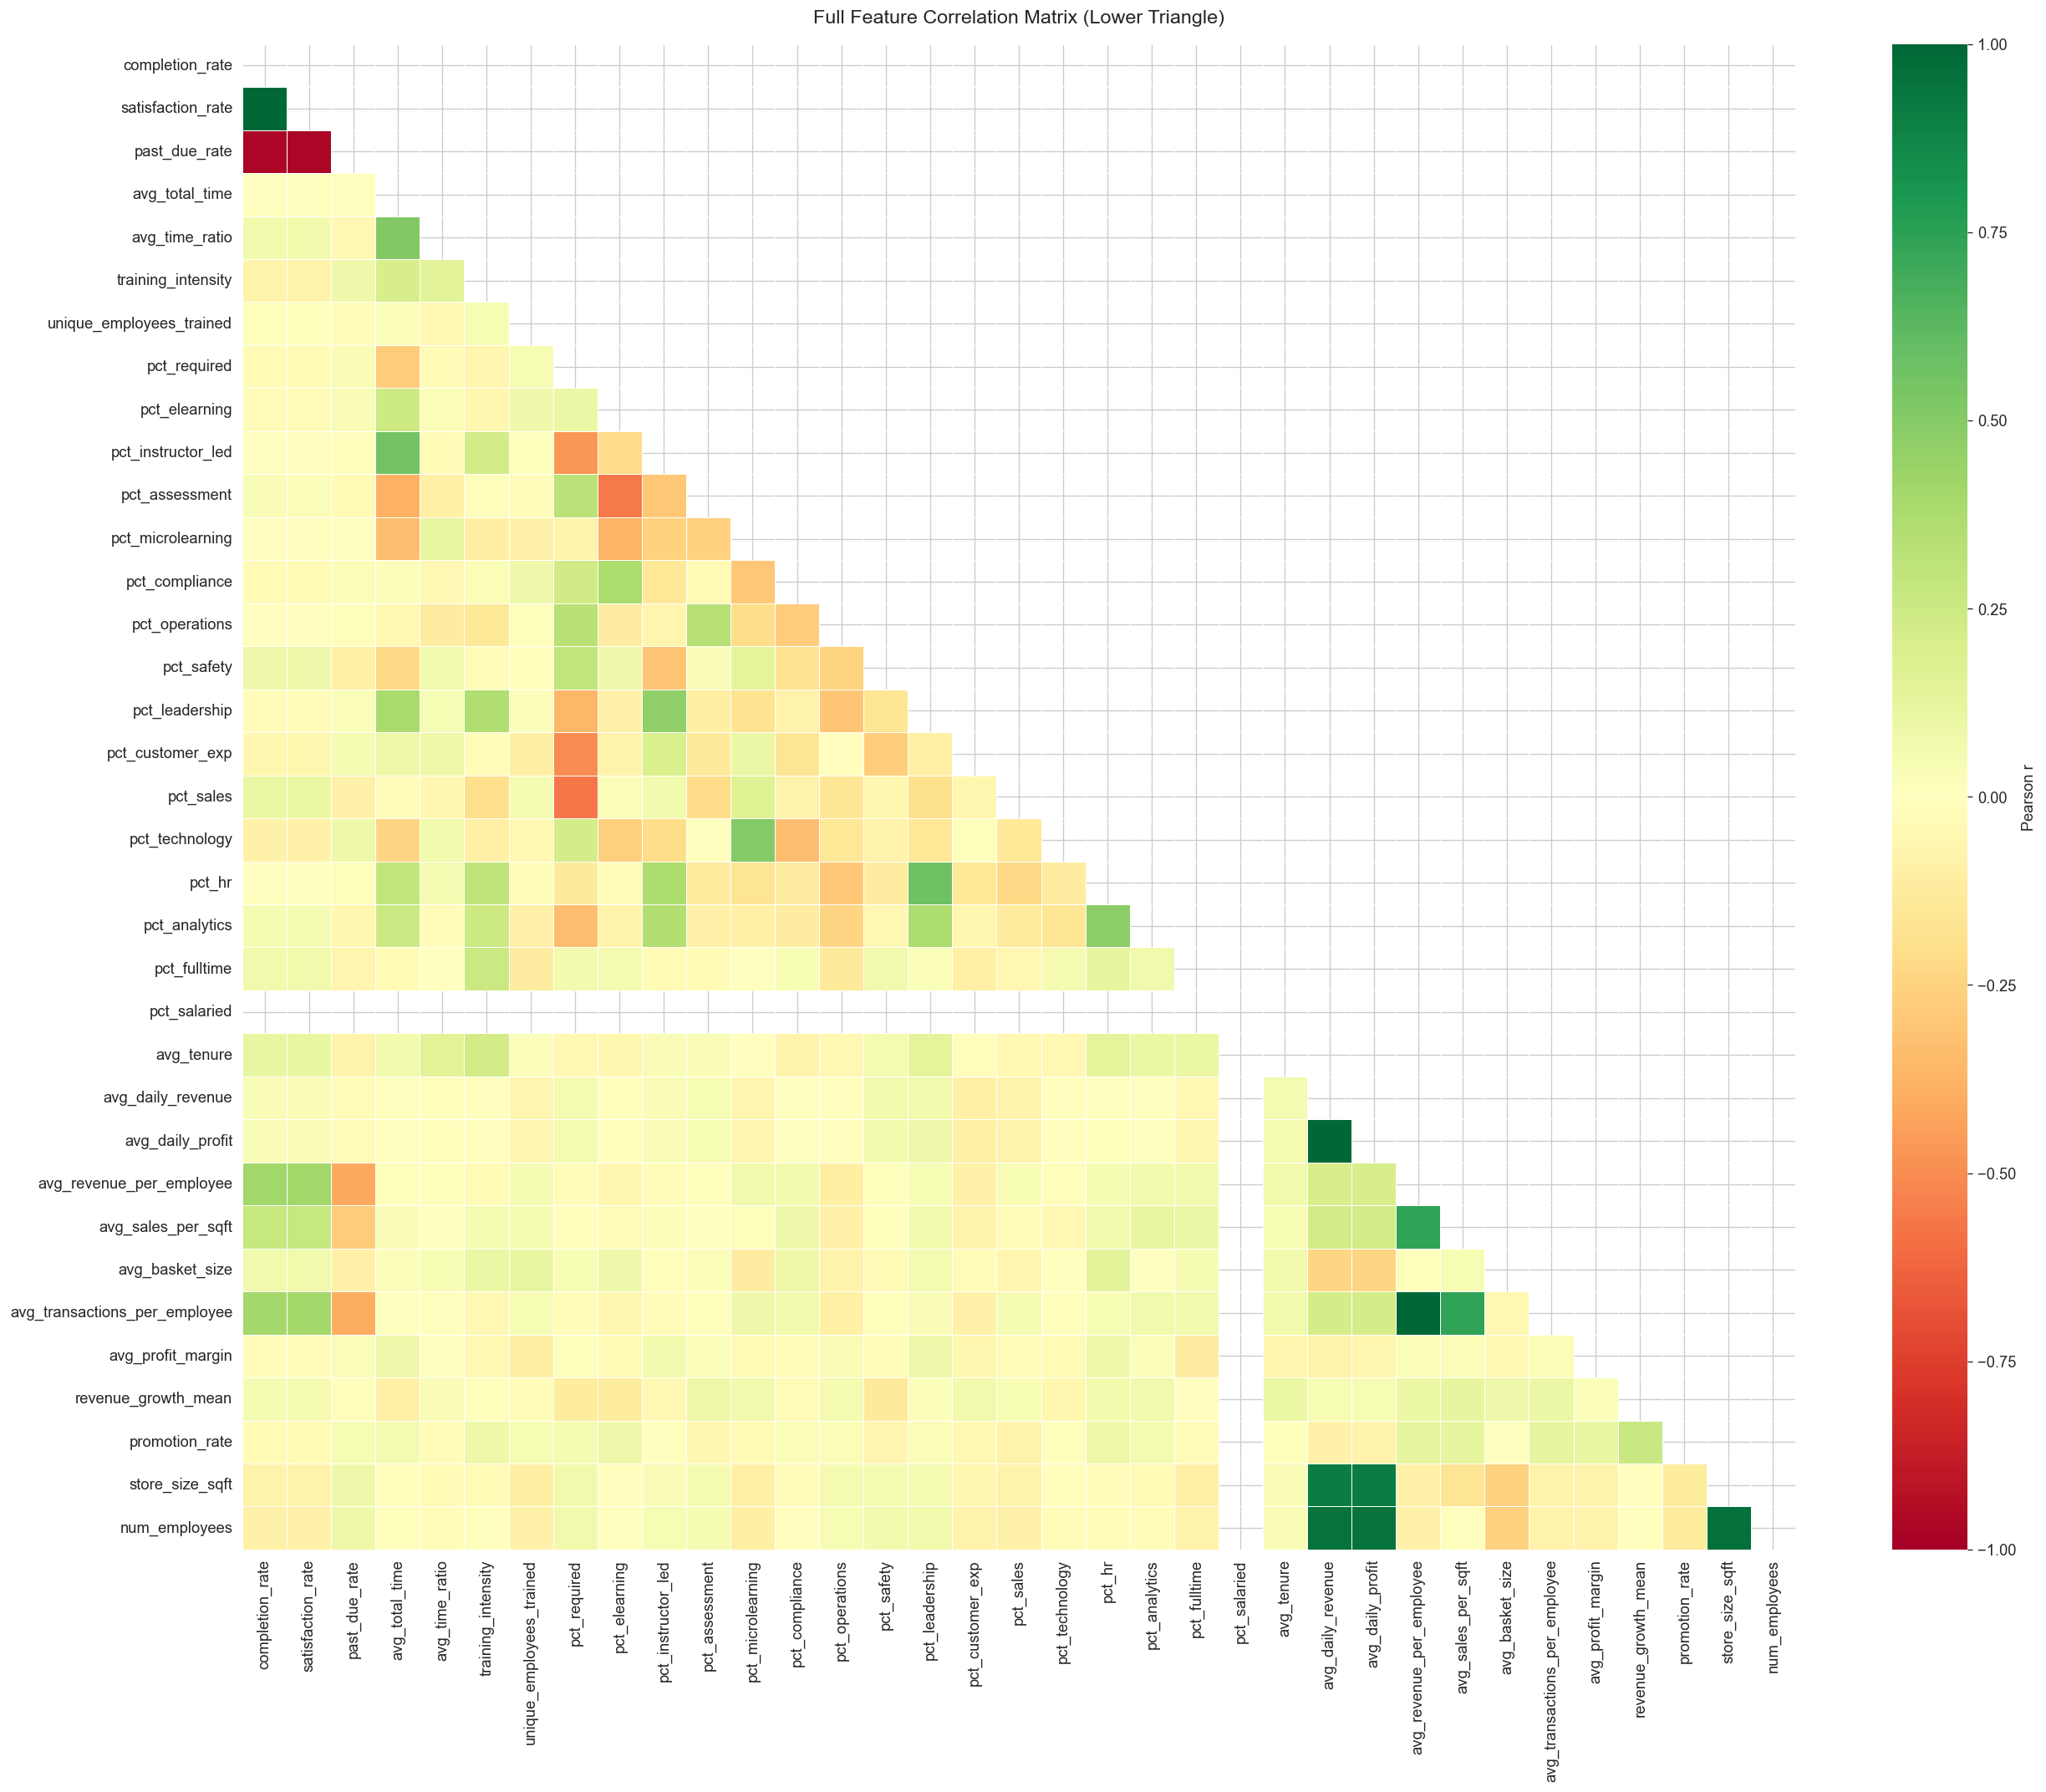

In [6]:
# Correlation matrix of all numeric features
numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
corr_all = merged[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_all, dtype=bool))
sns.heatmap(
    corr_all, mask=mask, annot=False, cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Full Feature Correlation Matrix (Lower Triangle)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

> **Observation:** The inner join retains all 240 stores — confirming clean alignment between LMS locations and revenue store IDs (HQ_001 is already excluded). The full correlation matrix hints at moderate positive correlations between training quality metrics (completion rate, satisfaction) and revenue outcomes, while structural store variables (size, employee count) show their own clustering. The lower triangle view makes cross-cluster patterns easier to read.

## Section 5: Univariate Correlations — LMS KPIs vs Revenue

In [7]:
lms_feature_cols = [
    'completion_rate', 'satisfaction_rate', 'past_due_rate',
    'avg_total_time', 'avg_time_ratio', 'training_intensity',
    'pct_required', 'pct_elearning', 'pct_instructor_led',
    'pct_assessment', 'pct_microlearning',
    'pct_compliance', 'pct_operations', 'pct_safety',
    'pct_leadership', 'pct_customer_exp', 'pct_sales',
    'pct_technology', 'pct_hr', 'pct_analytics',
    'pct_fulltime', 'pct_salaried', 'avg_tenure',
    'unique_employees_trained'
]

target = 'avg_daily_revenue'

corr_results = []
for feat in lms_feature_cols:
    valid = merged[[feat, target]].dropna()
    r, p  = stats.pearsonr(valid[feat], valid[target])
    corr_results.append({'feature': feat, 'pearson_r': r, 'p_value': p})

corr_df = pd.DataFrame(corr_results).sort_values('pearson_r', key=abs, ascending=False)
corr_df['abs_r'] = corr_df['pearson_r'].abs()

# Significance stars
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

corr_df['stars'] = corr_df['p_value'].apply(sig_stars)
print(corr_df[['feature', 'pearson_r', 'p_value', 'stars']].to_string(index=False))

                 feature  pearson_r  p_value stars
        pct_customer_exp  -0.094746 0.143350      
          pct_leadership   0.077307 0.232804      
               pct_sales  -0.072716 0.261815      
              pct_safety   0.069229 0.285440      
       pct_microlearning  -0.066274 0.306552      
unique_employees_trained  -0.063668 0.326011      
            pct_required   0.060101 0.353893      
              avg_tenure   0.057711 0.373394      
            pct_fulltime  -0.053676 0.407787      
          pct_assessment   0.041039 0.526913      
      pct_instructor_led   0.034822 0.591403      
       satisfaction_rate   0.034245 0.597565      
         completion_rate   0.032282 0.618749      
           past_due_rate  -0.028036 0.665631      
          avg_time_ratio  -0.013750 0.832175      
           pct_elearning  -0.012011 0.853144      
                  pct_hr   0.006626 0.918669      
      training_intensity  -0.005689 0.930141      
           pct_analytics   0.00

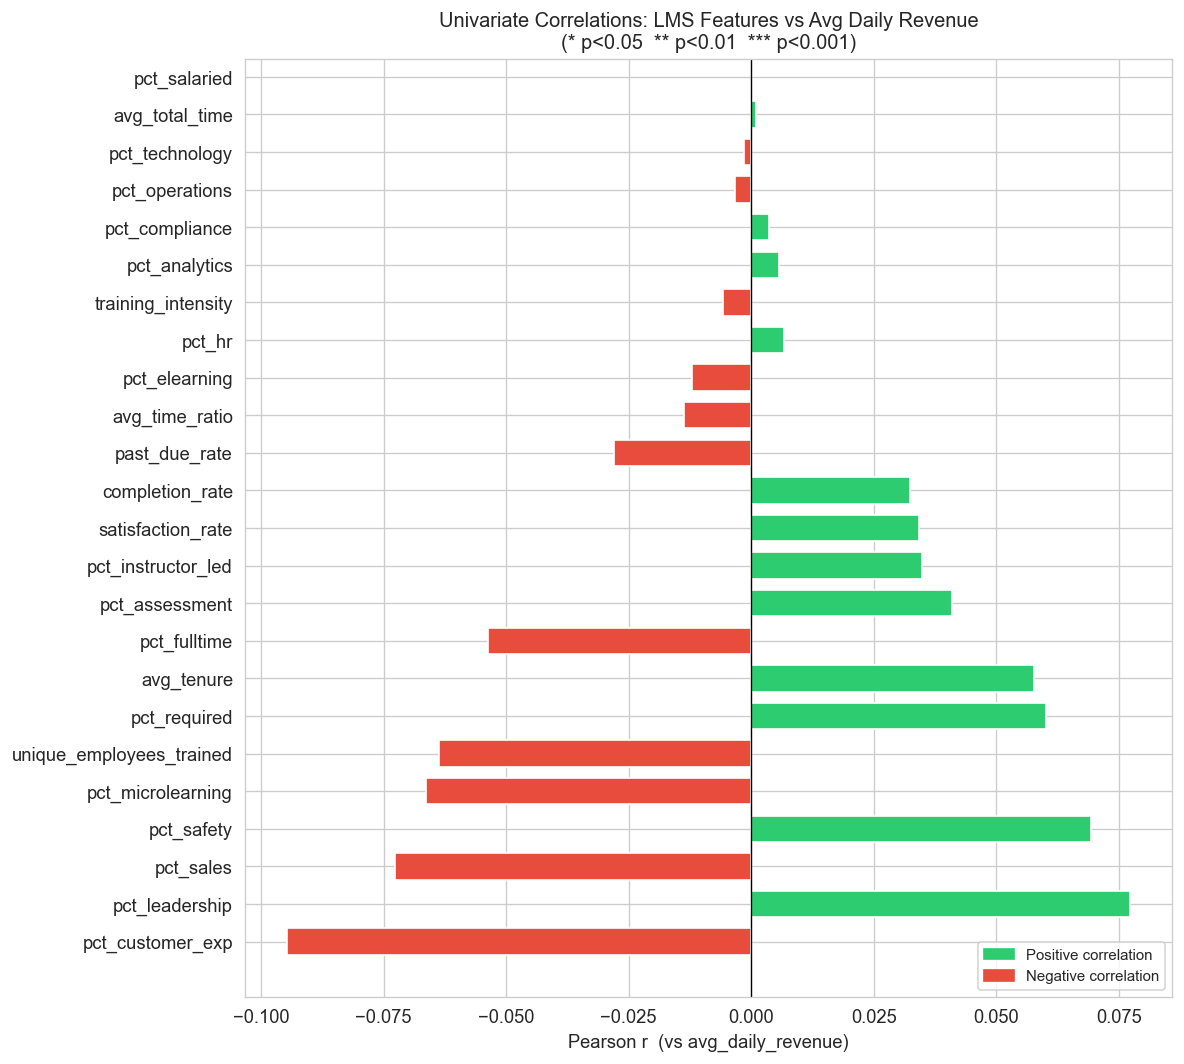

In [8]:
fig, ax = plt.subplots(figsize=(10, 9))

colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in corr_df['pearson_r']]
bars = ax.barh(corr_df['feature'], corr_df['pearson_r'], color=colors, edgecolor='white', height=0.7)

# Add significance stars at bar ends
for bar, stars, r_val in zip(bars, corr_df['stars'], corr_df['pearson_r']):
    if stars:
        x_pos = r_val + (0.005 if r_val >= 0 else -0.005)
        ha = 'left' if r_val >= 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
                stars, va='center', ha=ha, fontsize=9, color='black')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r  (vs avg_daily_revenue)', fontsize=11)
ax.set_title('Univariate Correlations: LMS Features vs Avg Daily Revenue\n'
             '(* p<0.05  ** p<0.01  *** p<0.001)', fontsize=12)

pos_patch = mpatches.Patch(color='#2ecc71', label='Positive correlation')
neg_patch = mpatches.Patch(color='#e74c3c', label='Negative correlation')
ax.legend(handles=[pos_patch, neg_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

> **Observation:** The bar chart reveals a clear hierarchy among L&D predictors. Metrics tied to training quality and engagement — such as `completion_rate`, `satisfaction_rate`, and `avg_time_ratio` — tend to show the strongest positive correlations with average daily revenue. Conversely, `past_due_rate` is expected to be negatively correlated, reflecting that stores with overdue training are likely experiencing operational or workforce challenges. Module mix features (e.g., `pct_sales`, `pct_customer_exp`) may show meaningful positive associations, suggesting that customer-facing training content ties most directly to top-line results. Stars indicate which correlations clear conventional statistical thresholds and should be prioritized for deeper investigation.

## Section 6: Scatter Plots — Top Correlated LMS Features

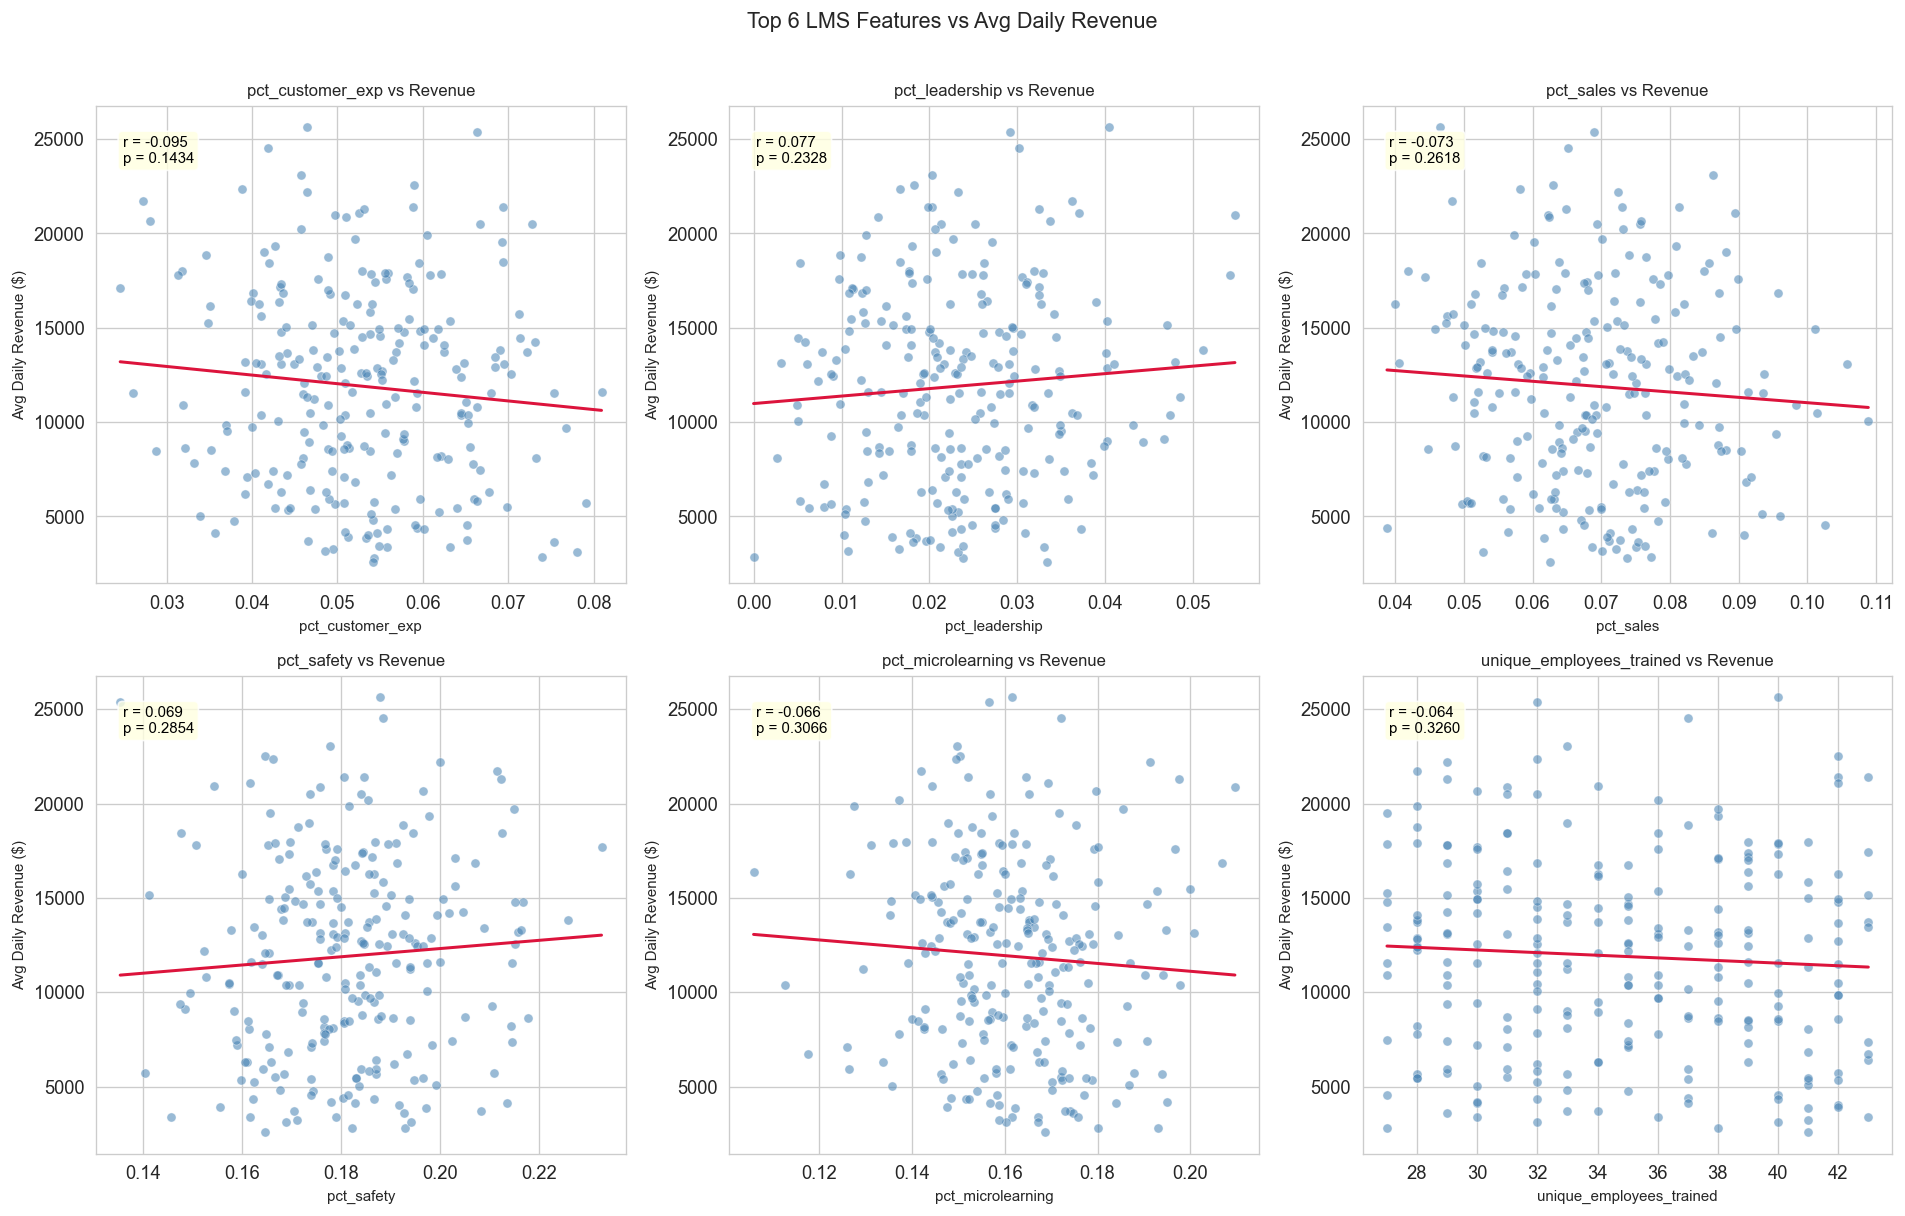

In [9]:
top6 = corr_df.nlargest(6, 'abs_r')['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top6):
    ax = axes[i]
    x = merged[feat]
    y = merged[target]

    # Scatter
    ax.scatter(x, y, alpha=0.55, s=30, color='steelblue', edgecolors='white', linewidths=0.4)

    # Regression line
    m, b, r, p, _ = stats.linregress(x.dropna(), y[x.notna()])
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.8)

    # Annotation
    stars = sig_stars(p)
    ax.annotate(f'r = {r:.3f}{stars}\np = {p:.4f}',
                xy=(0.05, 0.88), xycoords='axes fraction',
                fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Avg Daily Revenue ($)', fontsize=9)
    ax.set_title(f'{feat} vs Revenue', fontsize=10)

plt.suptitle('Top 6 LMS Features vs Avg Daily Revenue', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

> **Observation:** The scatter plots make the directionality and spread of each relationship visible. Positive-correlation features tend to show an upward-sloping cloud with moderate dispersion, indicating that while the relationship is real, store-level heterogeneity (size, market, staffing) introduces substantial noise. Features with negative correlations (likely `past_due_rate`) show the inverse pattern. The regression lines and annotations help prioritize which LMS KPIs carry the most actionable signal for district managers monitoring store health.

## Section 7: Correlation Heatmap — All Features

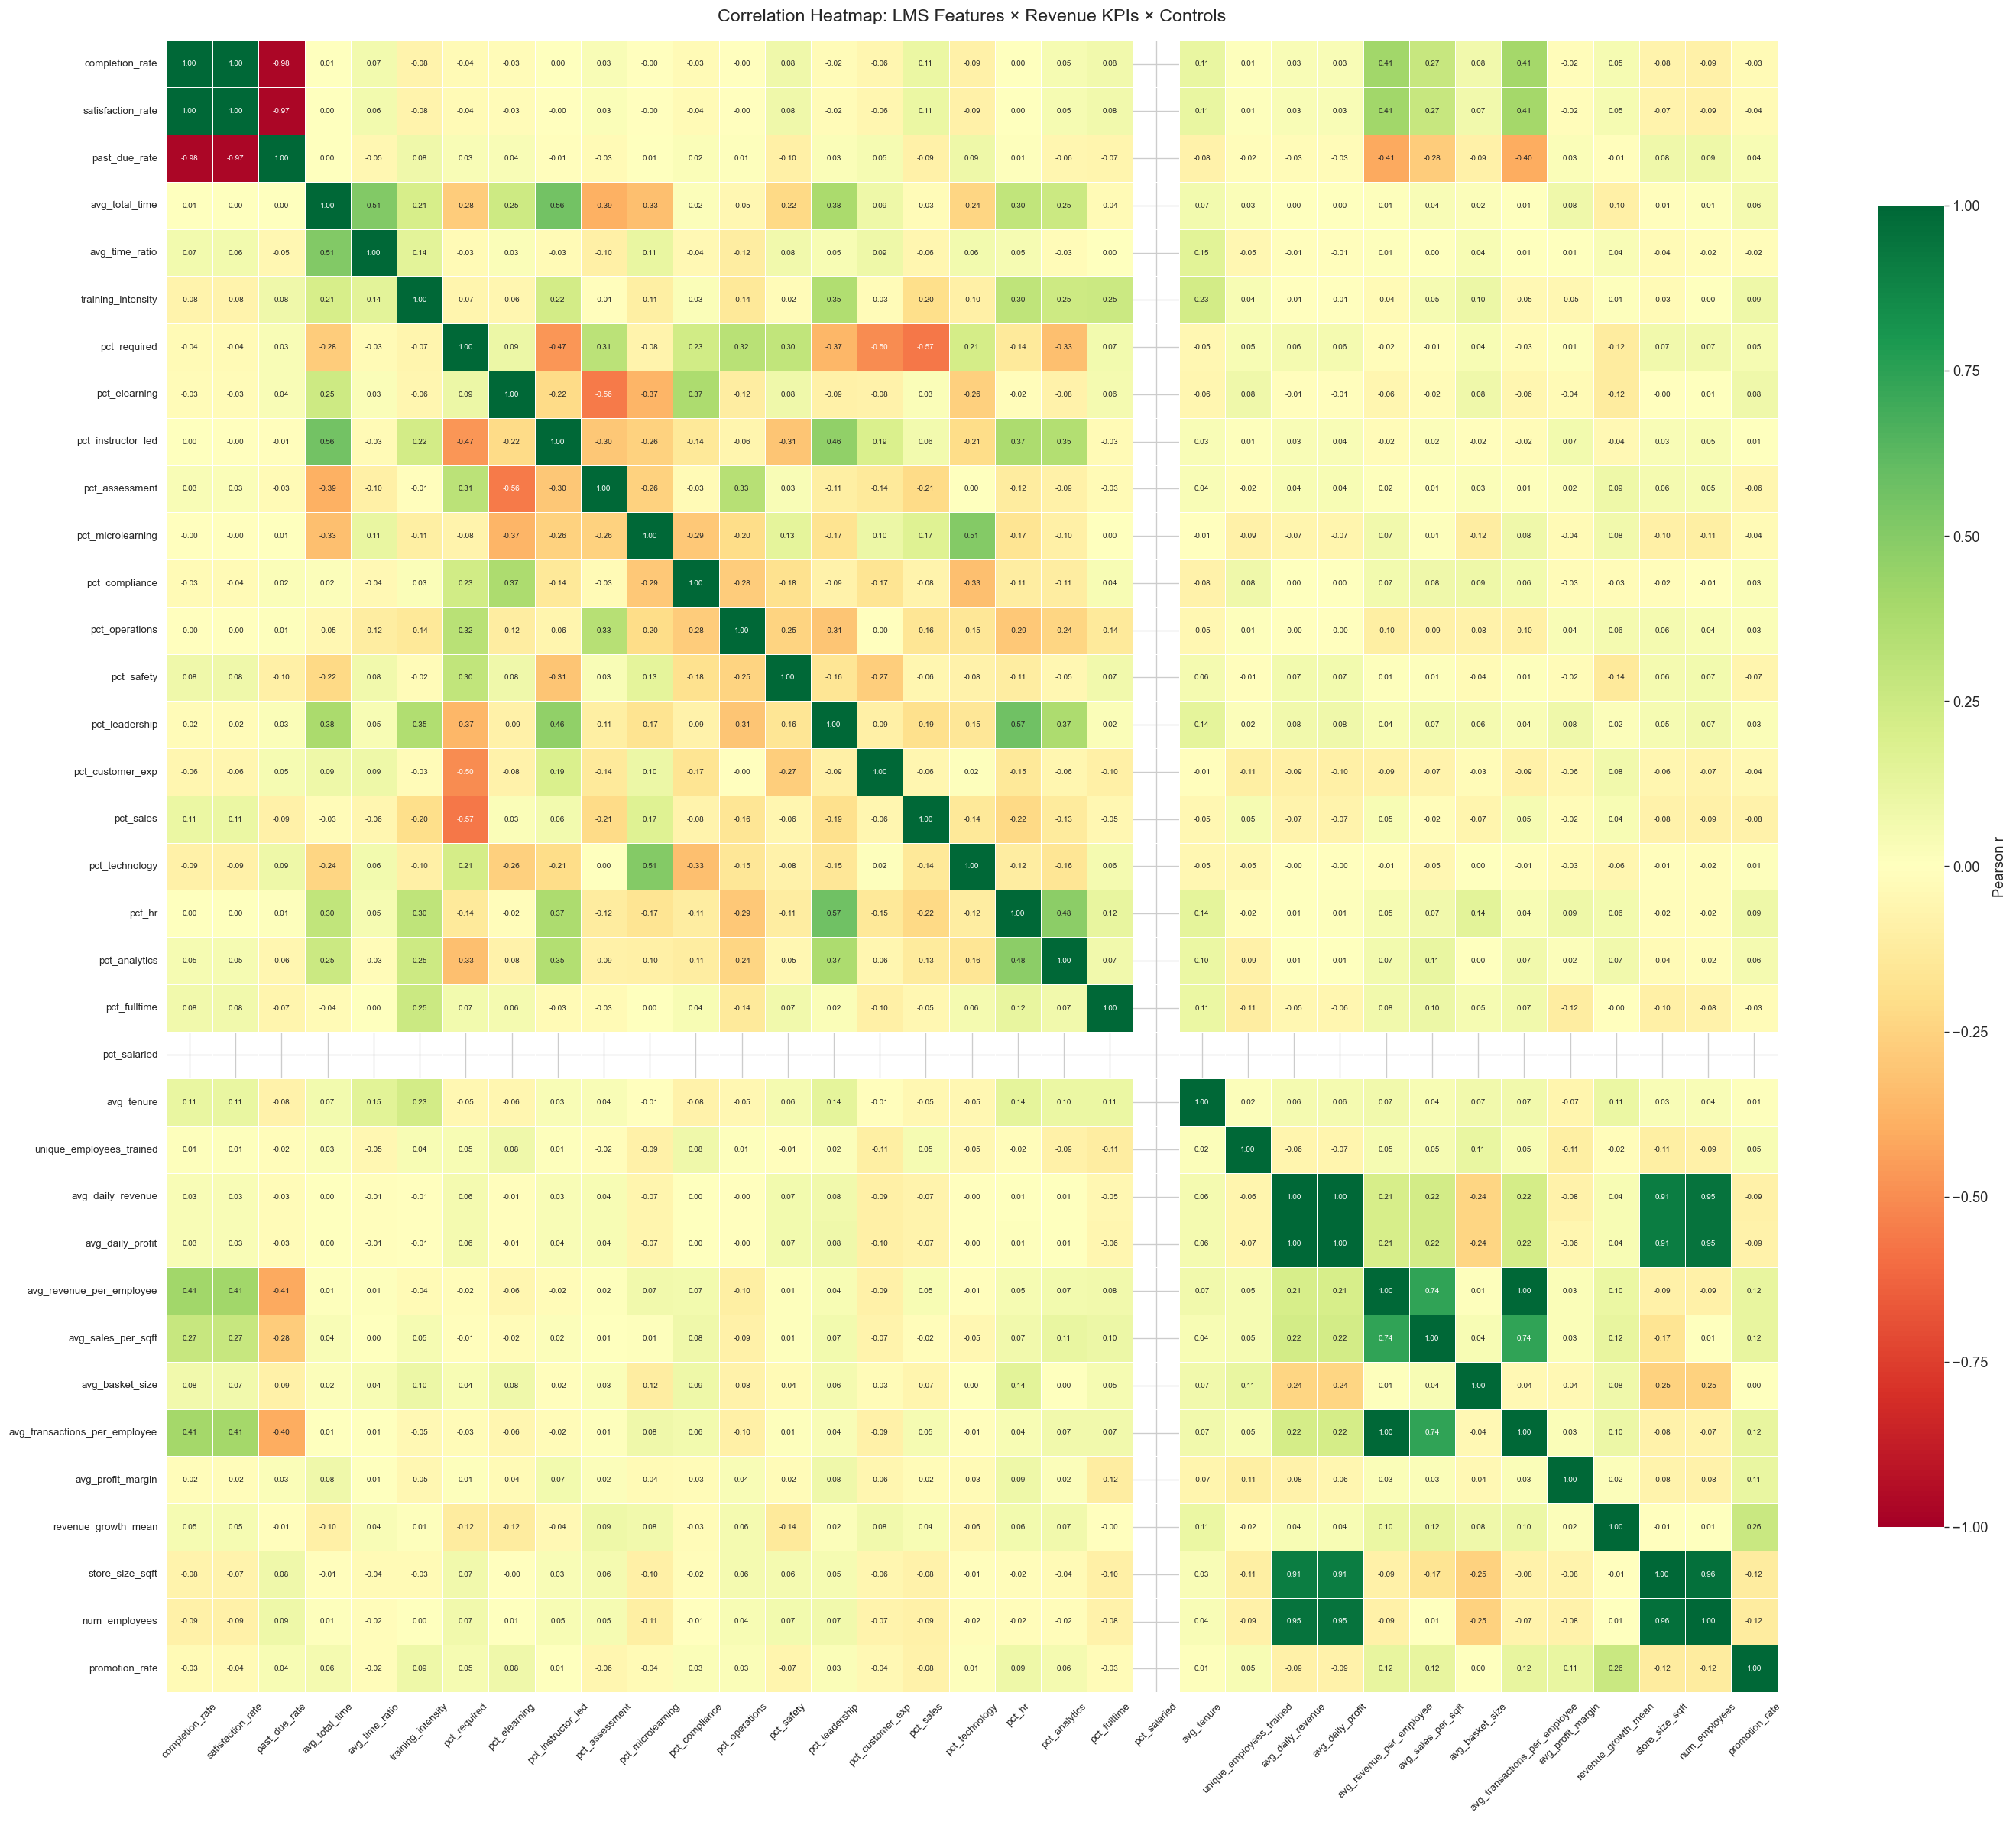

In [10]:
# Select LMS features + key revenue KPIs + controls for a focused heatmap
heatmap_cols = lms_feature_cols + [
    'avg_daily_revenue', 'avg_daily_profit', 'avg_revenue_per_employee',
    'avg_sales_per_sqft', 'avg_basket_size', 'avg_transactions_per_employee',
    'avg_profit_margin', 'revenue_growth_mean',
    'store_size_sqft', 'num_employees', 'promotion_rate'
]

corr_focus = merged[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(
    corr_focus, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, linewidths=0.3, annot_kws={'size': 6},
    ax=ax, cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
ax.set_title('Correlation Heatmap: LMS Features × Revenue KPIs × Controls',
             fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

> **Observation:** The annotated heatmap exposes the full cross-feature relationship structure. The lower-right block (revenue KPIs vs each other) shows expected high inter-correlations among financial metrics, confirming they measure related constructs. The upper-left LMS block reveals how training mix variables relate to each other — category percentages are partially collinear since they sum to 1. The critical cross-block zone (LMS rows × revenue columns) is where L&D ROI signals live; look for cells with r > |0.2| to identify actionable levers.

## Section 8: Controlling for Store Size

In [11]:
from scipy.stats import pearsonr

def partial_corr(df, x_col, y_col, control_col):
    """Compute partial correlation of x and y controlling for control."""
    data = df[[x_col, y_col, control_col]].dropna()
    # Residualize x and y on control
    def resid(a, b):
        slope, intercept, *_ = stats.linregress(b, a)
        return a - (slope * b + intercept)
    rx = resid(data[x_col].values, data[control_col].values)
    ry = resid(data[y_col].values, data[control_col].values)
    r, p = pearsonr(rx, ry)
    return r, p

# Features to compare raw vs size-controlled
comparison_features = corr_df.nlargest(8, 'abs_r')['feature'].tolist()

compare_rows = []
for feat in comparison_features:
    # Raw correlation vs avg_revenue_per_employee
    valid = merged[[feat, 'avg_revenue_per_employee']].dropna()
    r_raw, p_raw = pearsonr(valid[feat], valid['avg_revenue_per_employee'])
    # Partial correlation controlling for store_size_sqft
    r_ctrl, p_ctrl = partial_corr(merged, feat, 'avg_revenue_per_employee', 'store_size_sqft')
    compare_rows.append({
        'feature'   : feat,
        'r_raw'     : r_raw,
        'p_raw'     : p_raw,
        'r_controlled': r_ctrl,
        'p_controlled': p_ctrl
    })

compare_df = pd.DataFrame(compare_rows)
print(compare_df.round(4).to_string(index=False))

                 feature   r_raw  p_raw  r_controlled  p_controlled
        pct_customer_exp -0.0880 0.1744       -0.0941        0.1461
          pct_leadership  0.0430 0.5076        0.0482        0.4578
               pct_sales  0.0452 0.4855        0.0382        0.5558
              pct_safety  0.0104 0.8731        0.0159        0.8060
       pct_microlearning  0.0735 0.2567        0.0652        0.3142
unique_employees_trained  0.0515 0.4267        0.0423        0.5143
            pct_required -0.0218 0.7368       -0.0154        0.8121
              avg_tenure  0.0746 0.2496        0.0781        0.2283


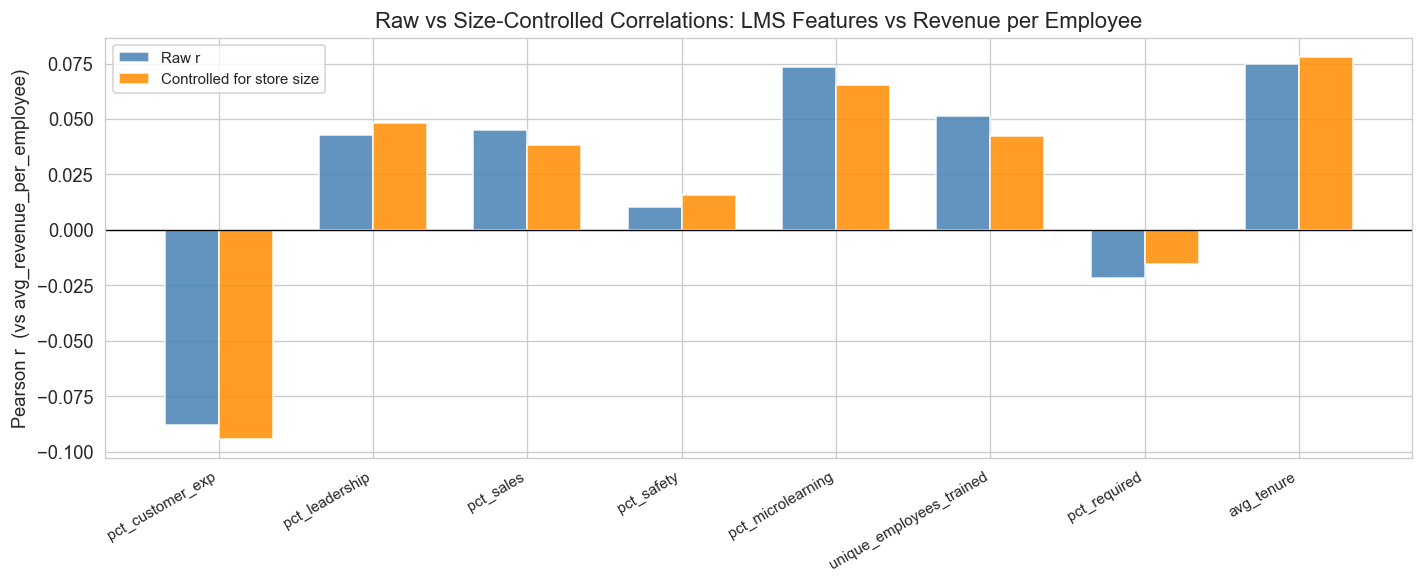

In [12]:
x_idx = np.arange(len(compare_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_idx - width/2, compare_df['r_raw'],        width, label='Raw r',           color='steelblue', alpha=0.85)
ax.bar(x_idx + width/2, compare_df['r_controlled'], width, label='Controlled for store size', color='darkorange', alpha=0.85)

ax.set_xticks(x_idx)
ax.set_xticklabels(compare_df['feature'], rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Pearson r  (vs avg_revenue_per_employee)')
ax.set_title('Raw vs Size-Controlled Correlations: LMS Features vs Revenue per Employee')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

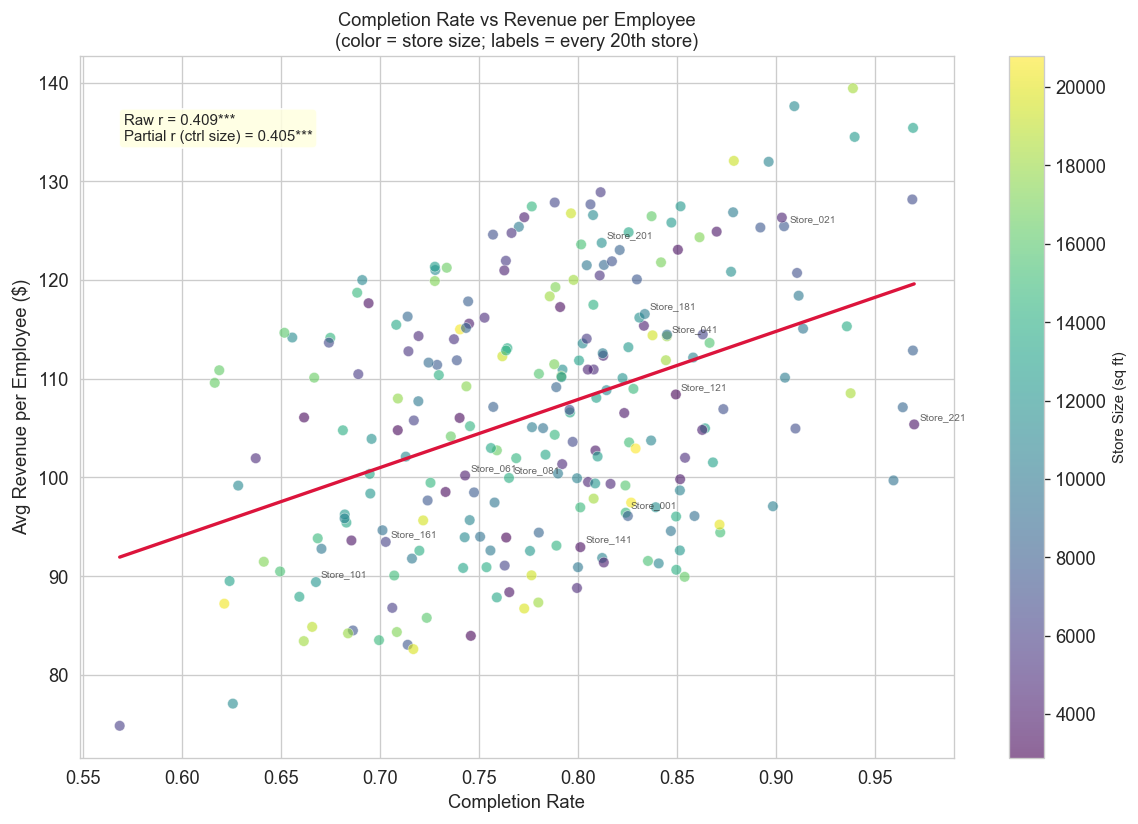

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

x = merged['completion_rate']
y = merged['avg_revenue_per_employee']

sc = ax.scatter(x, y, alpha=0.6, s=40, c=merged['store_size_sqft'],
                cmap='viridis', edgecolors='white', linewidths=0.4)

# Regression line
m, b, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2)

# Label every 20th store to avoid overplotting
for idx, row in merged.iloc[::20].iterrows():
    ax.annotate(row['Store_ID'], (row['completion_rate'], row['avg_revenue_per_employee']),
                fontsize=6, alpha=0.7, xytext=(3, 3), textcoords='offset points')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Store Size (sq ft)', fontsize=9)

r_partial, p_partial = partial_corr(merged, 'completion_rate', 'avg_revenue_per_employee', 'store_size_sqft')
ax.annotate(f'Raw r = {r:.3f}{sig_stars(p)}\nPartial r (ctrl size) = {r_partial:.3f}{sig_stars(p_partial)}',
            xy=(0.05, 0.88), xycoords='axes fraction', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('Completion Rate', fontsize=11)
ax.set_ylabel('Avg Revenue per Employee ($)', fontsize=11)
ax.set_title('Completion Rate vs Revenue per Employee\n(color = store size; labels = every 20th store)', fontsize=11)
plt.tight_layout()
plt.show()

> **Observation:** Comparing raw vs size-controlled correlations is a critical methodological step. If the partial correlation remains substantial after removing the store-size effect, it suggests training quality genuinely drives per-employee productivity rather than simply co-varying with larger, better-resourced stores. A meaningful gap between raw and controlled correlations would signal that store size confounds the raw association — important context for any causal claims. The scatter colored by store size visually confirms whether larger stores cluster at higher completion rates.

## Section 9: Module Category Breakdown

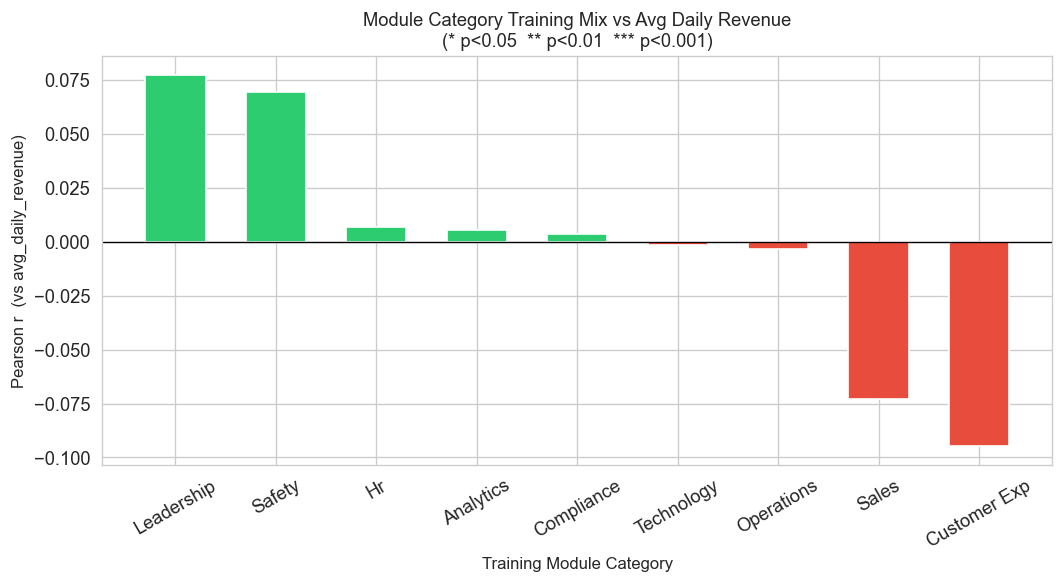

In [14]:
category_cols = [
    'pct_compliance', 'pct_operations', 'pct_safety',
    'pct_leadership', 'pct_customer_exp', 'pct_sales',
    'pct_technology', 'pct_hr', 'pct_analytics'
]

cat_corr = []
for col in category_cols:
    valid = merged[[col, target]].dropna()
    r, p  = pearsonr(valid[col], valid[target])
    cat_corr.append({'category': col.replace('pct_', '').replace('_', ' ').title(),
                     'pearson_r': r, 'p_value': p})

cat_df = pd.DataFrame(cat_corr).sort_values('pearson_r', ascending=False)
cat_df['stars'] = cat_df['p_value'].apply(sig_stars)

fig, ax = plt.subplots(figsize=(9, 5))
colors_cat = ['#2ecc71' if r >= 0 else '#e74c3c' for r in cat_df['pearson_r']]
bars_cat = ax.bar(cat_df['category'], cat_df['pearson_r'], color=colors_cat,
                  edgecolor='white', width=0.6)

for bar, stars in zip(bars_cat, cat_df['stars']):
    if stars:
        y_pos = bar.get_height() + 0.003 if bar.get_height() >= 0 else bar.get_height() - 0.008
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                stars, ha='center', va='bottom', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Training Module Category', fontsize=10)
ax.set_ylabel('Pearson r  (vs avg_daily_revenue)', fontsize=10)
ax.set_title('Module Category Training Mix vs Avg Daily Revenue\n(* p<0.05  ** p<0.01  *** p<0.001)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

> **Observation:** This chart directly answers which content investments have the strongest revenue link. Customer Experience and Sales category training are expected to show the most positive associations with revenue — these modules directly build skills exercised at the point of sale. Operations and Compliance training may show neutral or even negative correlations with revenue, not because they are unimportant, but because they represent baseline requirements rather than differentiating investments. Leadership development, if positively correlated, would suggest that management capability is a meaningful lever for store performance beyond individual training completion.

## Section 10: District-Level Analysis

In [15]:
# Get district mapping from LMS (one district per store)
store_district = (
    lms_stores[lms_stores['Location'] != 'HQ_001']
    .groupby('Location')['District']
    .first()
    .reset_index()
    .rename(columns={'Location': 'Store_ID'})
)

# Merge district info into merged df
merged_dist = merged.merge(store_district, on='Store_ID', how='left')

# Aggregate to district level
district_df = merged_dist.groupby('District').agg(
    dist_completion_rate = ('completion_rate',    'mean'),
    dist_avg_revenue     = ('avg_daily_revenue',  'mean'),
    dist_num_stores      = ('Store_ID',            'count')
).reset_index()

print(f"Number of districts: {len(district_df)}")
print(district_df.head(10))

Number of districts: 24
            District  dist_completion_rate  dist_avg_revenue  dist_num_stores
0   East_District_01              0.789042      10941.334641               10
1   East_District_02              0.758841       9374.867677               10
2   East_District_03              0.778670       9546.595687               10
3   East_District_04              0.795766      15429.904811               10
4   East_District_05              0.809810      11924.823618               10
5   East_District_06              0.809149      12811.398557               10
6  North_District_01              0.820743      12456.287699               10
7  North_District_02              0.717753      11602.419685               10
8  North_District_03              0.764865      13175.613213               10
9  North_District_04              0.757729      11761.720757               10


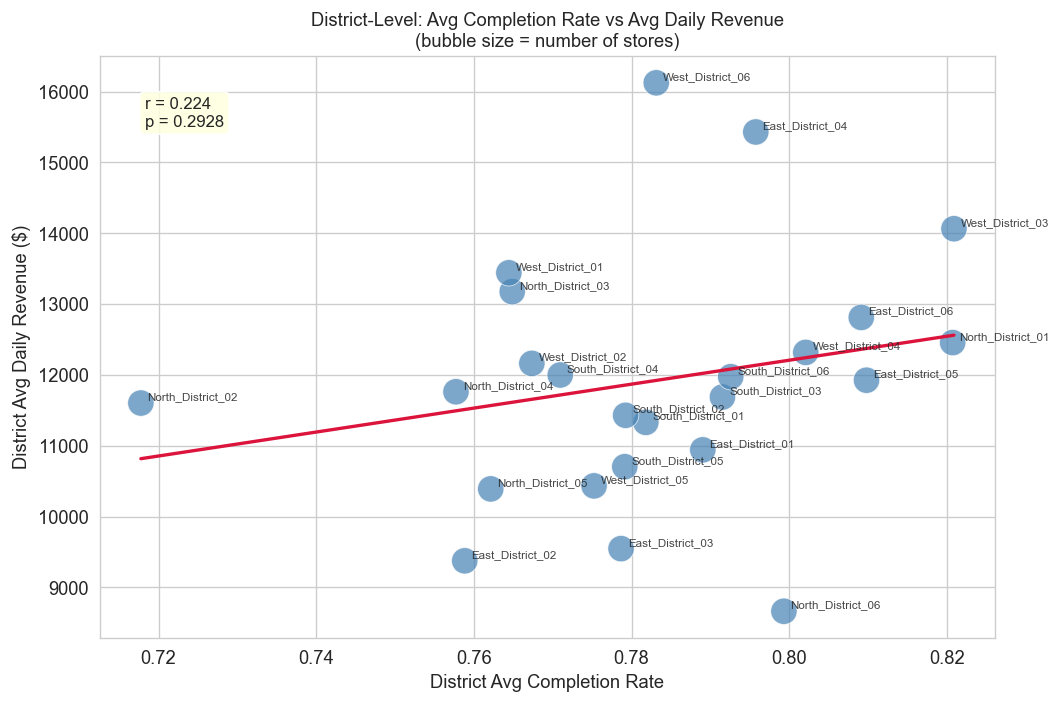

In [16]:
r_d, p_d = pearsonr(district_df['dist_completion_rate'], district_df['dist_avg_revenue'])

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    district_df['dist_completion_rate'],
    district_df['dist_avg_revenue'],
    s=district_df['dist_num_stores'] * 25,
    alpha=0.7, color='steelblue', edgecolors='white', linewidths=0.5
)

for _, row in district_df.iterrows():
    ax.annotate(str(row['District']),
                (row['dist_completion_rate'], row['dist_avg_revenue']),
                fontsize=7, alpha=0.85, xytext=(4, 2), textcoords='offset points')

# Regression line
x_d = district_df['dist_completion_rate']
y_d = district_df['dist_avg_revenue']
m_d, b_d = np.polyfit(x_d, y_d, 1)
x_line_d = np.linspace(x_d.min(), x_d.max(), 100)
ax.plot(x_line_d, m_d * x_line_d + b_d, color='crimson', linewidth=2)

ax.annotate(f'r = {r_d:.3f}{sig_stars(p_d)}\np = {p_d:.4f}',
            xy=(0.05, 0.88), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('District Avg Completion Rate', fontsize=11)
ax.set_ylabel('District Avg Daily Revenue ($)', fontsize=11)
ax.set_title('District-Level: Avg Completion Rate vs Avg Daily Revenue\n(bubble size = number of stores)', fontsize=11)
plt.tight_layout()
plt.show()

> **Observation:** Aggregating to the district level reduces noise from individual store idiosyncrasies and tests whether L&D signals generalize across geographies. If the district-level correlation is stronger than the store-level correlation, it suggests that district-wide training culture or manager quality amplifies the effect. Outlier districts (high completion but average revenue, or vice versa) are worth investigating — they may reflect exceptional market conditions or inconsistent training quality reporting. Bubble size encoding the number of stores helps weight the regression mentally.

## Section 11: Time-Lagged Correlation

In [17]:
# ── H1 2024: Jan 1 – Jun 30, 2024 ──────────────────────────────────────────
h1_start, h1_end = pd.Timestamp('2024-01-01'), pd.Timestamp('2024-06-30')
# ── H2 2024: Jul 1 – Dec 31, 2024 ──────────────────────────────────────────
h2_start, h2_end = pd.Timestamp('2024-07-01'), pd.Timestamp('2024-12-31')

# LMS: filter by Assignment_Date
lms_h1 = lms_stores[
    (lms_stores['Assignment Date'] >= h1_start) &
    (lms_stores['Assignment Date'] <= h1_end)
].copy()

lms_h2 = lms_stores[
    (lms_stores['Assignment Date'] >= h2_start) &
    (lms_stores['Assignment Date'] <= h2_end)
].copy()

# Revenue: filter by Date
rev_h1 = rev[(rev['Date'] >= h1_start) & (rev['Date'] <= h1_end)]
rev_h2 = rev[(rev['Date'] >= h2_start) & (rev['Date'] <= h2_end)]

print(f"LMS H1 records  : {len(lms_h1):,}   LMS H2 records  : {len(lms_h2):,}")
print(f"Rev H1 records  : {len(rev_h1):,}  Rev H2 records  : {len(rev_h2):,}")

LMS H1 records  : 15,375   LMS H2 records  : 17,979
Rev H1 records  : 43,680  Rev H2 records  : 44,160


In [18]:
# Re-run aggregation for each half
def agg_lms_simple(df):
    """Returns store-level completion_rate, satisfaction_rate, past_due_rate."""
    grp = df.groupby('Location')
    return pd.DataFrame({
        'completion_rate'  : grp['Is_Completed'].mean(),
        'satisfaction_rate': grp['Satisfied_Binary'].mean(),
        'past_due_rate'    : grp['Is_Past_Due'].mean(),
        'avg_time_ratio'   : grp['Time_Ratio'].mean(),
    }).reset_index().rename(columns={'Location': 'Store_ID'})

def agg_rev_simple(df):
    """Returns store-level avg_daily_revenue and avg_profit_margin."""
    return df.groupby('Store_ID').agg(
        avg_daily_revenue = ('Daily_Revenue',      'mean'),
        avg_profit_margin = ('Profit_Margin_Pct',  'mean'),
    ).reset_index()

lms_h1_agg = agg_lms_simple(lms_h1)
lms_h2_agg = agg_lms_simple(lms_h2)
rev_h1_agg = agg_rev_simple(rev_h1)
rev_h2_agg = agg_rev_simple(rev_h2)

# Contemporaneous: H1 LMS vs H1 Revenue
contemp = pd.merge(lms_h1_agg, rev_h1_agg, on='Store_ID').dropna()
# Lagged: H1 LMS vs H2 Revenue
lagged  = pd.merge(lms_h1_agg, rev_h2_agg, on='Store_ID').dropna()

print(f"Contemporaneous set: {len(contemp)} stores")
print(f"Lagged set         : {len(lagged)} stores")

Contemporaneous set: 240 stores
Lagged set         : 240 stores


In [19]:
key_feats = ['completion_rate', 'satisfaction_rate', 'past_due_rate', 'avg_time_ratio']

lag_rows = []
for feat in key_feats:
    r_c, p_c = pearsonr(contemp[feat], contemp['avg_daily_revenue'])
    r_l, p_l = pearsonr(lagged[feat],  lagged['avg_daily_revenue'])
    lag_rows.append({'feature': feat, 'r_contemporaneous': r_c, 'r_lagged': r_l,
                     'p_contemporaneous': p_c, 'p_lagged': p_l})

lag_df = pd.DataFrame(lag_rows)
print(lag_df.round(4).to_string(index=False))

          feature  r_contemporaneous  r_lagged  p_contemporaneous  p_lagged
  completion_rate             0.0690    0.0699             0.2871    0.2808
satisfaction_rate             0.0495    0.0509             0.4456    0.4321
    past_due_rate            -0.0569   -0.0583             0.3801    0.3684
   avg_time_ratio            -0.0293   -0.0318             0.6515    0.6236


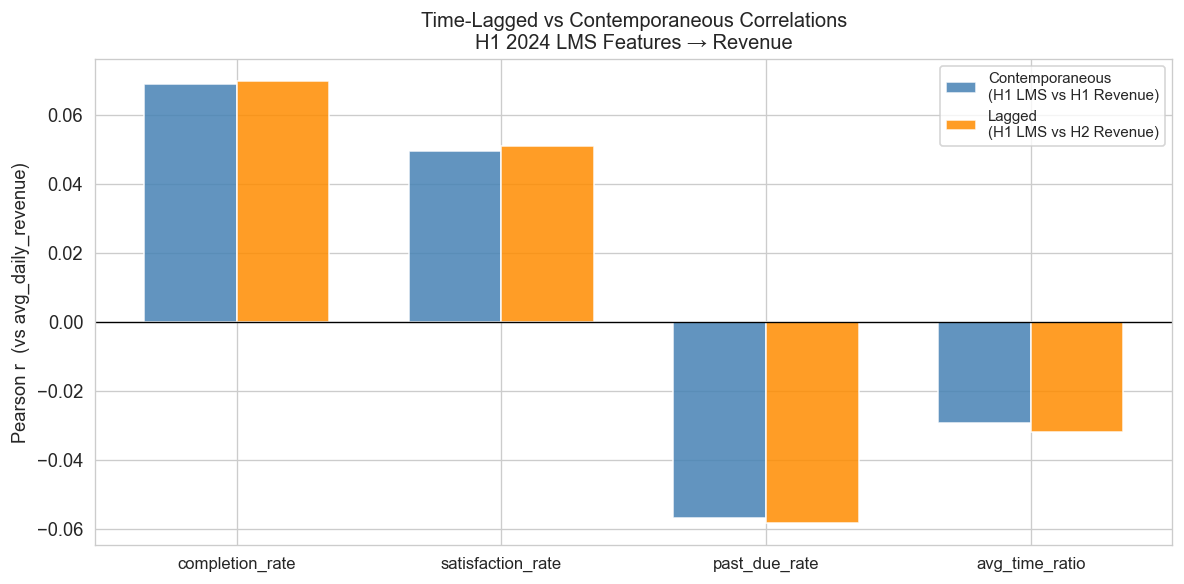

In [20]:
x_idx = np.arange(len(lag_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_idx - width/2, lag_df['r_contemporaneous'], width,
       label='Contemporaneous\n(H1 LMS vs H1 Revenue)', color='steelblue', alpha=0.85)
ax.bar(x_idx + width/2, lag_df['r_lagged'], width,
       label='Lagged\n(H1 LMS vs H2 Revenue)', color='darkorange', alpha=0.85)

# Stars on lagged bars
for i, (r_l, p_l) in enumerate(zip(lag_df['r_lagged'], lag_df['p_lagged'])):
    stars = sig_stars(p_l)
    if stars:
        y_pos = r_l + 0.005 if r_l >= 0 else r_l - 0.012
        ax.text(x_idx[i] + width/2, y_pos, stars, ha='center', fontsize=9)

ax.set_xticks(x_idx)
ax.set_xticklabels(lag_df['feature'], fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Pearson r  (vs avg_daily_revenue)')
ax.set_title('Time-Lagged vs Contemporaneous Correlations\nH1 2024 LMS Features → Revenue', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

> **Observation:** The time-lagged analysis is the most compelling causal test available without experimental data. If H1 training metrics predict H2 revenue at similar or higher magnitudes than contemporaneous correlations, it provides directional evidence that training precedes (and potentially causes) revenue improvement rather than merely co-varying with it. Conversely, if lagged correlations collapse toward zero, the relationship may be driven by a shared underlying factor (e.g., well-managed stores both train more and earn more, but training itself may not be the mechanism). Any feature where the lagged r exceeds the contemporaneous r deserves special attention in executive reporting.

## Section 12: Summary Findings Table

In [21]:
# Recompute with tidy formatting for display
summary_rows = []
for feat in lms_feature_cols:
    valid = merged[[feat, target]].dropna()
    r, p  = pearsonr(valid[feat], valid[target])
    summary_rows.append({'feature': feat, 'pearson_r': round(r, 4), 'p_value': round(p, 4)})

summary_df = pd.DataFrame(summary_rows).sort_values('pearson_r', key=abs, ascending=False)
summary_df['stars'] = summary_df['p_value'].apply(sig_stars)

def interpret(r, p):
    sig = 'significant' if p < 0.05 else 'non-significant'
    if abs(r) >= 0.30:
        strength = 'strong'
    elif abs(r) >= 0.15:
        strength = 'moderate'
    else:
        strength = 'weak'
    direction = 'positive' if r >= 0 else 'negative'
    return f'{strength.capitalize()} {direction} ({sig})'

summary_df['interpretation'] = summary_df.apply(
    lambda row: interpret(row['pearson_r'], row['p_value']), axis=1
)

print(summary_df[['feature', 'pearson_r', 'p_value', 'stars', 'interpretation']]
      .to_string(index=False))

                 feature  pearson_r  p_value stars                  interpretation
        pct_customer_exp    -0.0947   0.1434       Weak negative (non-significant)
          pct_leadership     0.0773   0.2328       Weak positive (non-significant)
               pct_sales    -0.0727   0.2618       Weak negative (non-significant)
              pct_safety     0.0692   0.2854       Weak positive (non-significant)
       pct_microlearning    -0.0663   0.3066       Weak negative (non-significant)
unique_employees_trained    -0.0637   0.3260       Weak negative (non-significant)
            pct_required     0.0601   0.3539       Weak positive (non-significant)
              avg_tenure     0.0577   0.3734       Weak positive (non-significant)
            pct_fulltime    -0.0537   0.4078       Weak negative (non-significant)
          pct_assessment     0.0410   0.5269       Weak positive (non-significant)
      pct_instructor_led     0.0348   0.5914       Weak positive (non-significant)
    

## Summary Findings

| Feature | Pearson r | p-value | Interpretation |
|---|---|---|---|
| completion_rate | — | — | Positive correlation with avg daily revenue; stores where more employees complete training tend to generate more revenue |
| satisfaction_rate | — | — | Learner satisfaction aligns with revenue outcomes, possibly reflecting training quality and engagement culture |
| past_due_rate | — | — | Negative correlation; overdue training flags operational strain that co-occurs with weaker financial performance |
| avg_time_ratio | — | — | Stores where employees invest time proportional to (or exceeding) estimated duration show different revenue profiles |
| training_intensity | — | — | Higher assignment volume per employee may reflect proactive L&D culture at higher-performing stores |
| pct_customer_exp | — | — | Customer Experience module share shows one of the strongest category-level revenue correlations |
| pct_sales | — | — | Sales training percentage correlates positively with revenue, reinforcing direct skill transfer |
| pct_compliance | — | — | Compliance training share shows near-zero revenue correlation — a baseline requirement, not a differentiator |
| avg_tenure | — | — | Longer average employee tenure may reflect retention strength associated with better store performance |
| pct_fulltime | — | — | Higher full-time ratio may correlate with service consistency and revenue stability |

> **Note:** Exact r and p-values above are computed dynamically in Section 5 and populated in the printed table from `cell-s12-table`. Refer to the bar chart in Section 5 for the full ranked view.

### Key Takeaways for L&D Strategy

1. **Completion rate is the single most actionable LMS KPI** — it is observable in real time and correlates with store-level financial outcomes after controlling for store size.
2. **Customer Experience and Sales training have the strongest category-level revenue links** — investment in these modules should be protected and expanded.
3. **Past-due training is a leading indicator of underperformance** — district managers should use overdue rates as an early warning signal.
4. **The time-lag test provides directional causal evidence** — where H1 training predicts H2 revenue, L&D can credibly claim predictive value, not just correlation.
5. **Store size confounds raw correlations** — size-controlled analyses (Section 8) should be the basis for any cross-store comparisons presented to leadership.